# Acute Nasopharyngitis (Common Cold) - Drug Prescription Demand Prediction

**Final Machine Learning Project | Regression Analysis for Medicine Demand Forecasting**

**Prepared for:** Management Team

---

## 1. Business Understanding & Objective

Acute nasopharyngitis, commonly known as the **common cold**, is one of the most frequently
treated conditions in our clinics (FAPs). Every month each clinic records:

- **tblDisease.Cases** - number of Acute Nasopharyngitis cases seen,
- **Drug** - the medicine prescribed,
- **Count** - how many prescriptions of that drug were issued.

**Business problem:** Management needs to know *how much of each medicine will be needed per
clinic each month* so that procurement, inventory and staffing can be planned ahead instead of
reacting to shortages.

**Machine learning objective:** Build a **regression model** that predicts the number of drug
prescriptions (`Count`) for a given month, clinic and drug, using historical data.

**Success criteria:** the model should minimise prediction error (RMSE / MAE) and explain the
variability in demand (R-squared), while being simple enough for management to trust and act on.

---

## 2. Setup - Libraries

This notebook runs on **Azure Machine Learning Notebook** (Python 3 + Jupyter).
All libraries below are pre-installed in the Azure ML default compute environment.


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-learn (ML)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_error

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries loaded successfully.')


All libraries loaded successfully.


---

## 3. Load the Dataset

The file `AcuteNasopharyngitis.xlsx` must be uploaded to the **same folder** as this notebook
in the Azure ML Studio. We read the `Sheet1` worksheet with pandas.


In [2]:
FILE_PATH = 'AcuteNasopharyngitis.xlsx'

df = pd.read_excel(FILE_PATH, sheet_name='Sheet1')
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(10)

Dataset shape: 223 rows x 6 columns


,Month,CLINIC/FAP,Assessment,tblDisease.Cases,Drug,Count
0,2025-01-01,CLINIC KM73,Acute nasopharyngitis [common cold],25.000,PARACETAMOL/ACETAMINOPHEN TAB 500 MG,13
1,2025-01-01,CLINIC KM73,Acute nasopharyngitis [common cold],25.000,MULTIVITAMIN,3
2,2025-01-01,CLINIC KM73,Acute nasopharyngitis [common cold],25.000,"DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG,...",7
3,2025-01-01,CLINIC KM73,Acute nasopharyngitis [common cold],25.000,MAG/ALUMINUM OH TAB 200MG,2
4,2025-01-01,FAP LW,Acute nasopharyngitis [common cold],16.000,"DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG,...",5
5,2025-01-01,FAP LW,Acute nasopharyngitis [common cold],16.000,PARACETAMOL/ACETAMINOPHEN TAB 500 MG,6
6,2025-01-01,CLINIC KELANIS,Acute nasopharyngitis [common cold],45.000,"DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG,...",8
7,2025-01-01,CLINIC KELANIS,Acute nasopharyngitis [common cold],45.000,MULTIVITAMIN,15
8,2025-01-01,CLINIC KELANIS,Acute nasopharyngitis [common cold],45.000,PARACETAMOL/ACETAMINOPHEN TAB 500 MG,18
9,2025-01-01,CLINIC KELANIS,Acute nasopharyngitis [common cold],45.000,MAG/ALUMINUM OH TAB 200MG,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Month             223 non-null    datetime64[ns]
 1   CLINIC/FAP        223 non-null    object        
 2   Assessment        223 non-null    object        
 3   tblDisease.Cases  207 non-null    float64       
 4   Drug              223 non-null    object        
 5   Count             223 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 10.6+ KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Month,223,NaN,NaN,NaN,2025-10-08 14:05:55.156950784,2025-01-01 00:00:00,2025-06-16 00:00:00,2025-11-01 00:00:00,2026-02-01 00:00:00,2026-07-01 00:00:00,NaN
CLINIC/FAP,223,6,CLINIC KM73,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Assessment,223,2,Acute nasopharyngitis [common cold],222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tblDisease.Cases,207.000,NaN,NaN,NaN,13.097,1.000,7.000,11.000,18.500,45.000,9.039
Drug,223,4,"DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG,...",87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,223.000,NaN,NaN,NaN,4.601,1.000,1.000,3.000,6.000,20.000,4.206


In [5]:
print('Missing values per column:')
print(df.isna().sum())
print()
print(f'Period covered: {df["Month"].min().date()} to {df["Month"].max().date()}')

Missing values per column:
Month                0
CLINIC/FAP           0
Assessment           0
tblDisease.Cases    16
Drug                 0
Count                0
dtype: int64

Period covered: 2025-01-01 to 2026-07-01


---

## 4. Data Cleaning & Preparation

Before modelling we fix several **data-quality issues** found in the raw file:

1. **Clinic names** have inconsistent casing, e.g. `Clinic Kelanis` vs `CLINIC KELANIS`
   - these are the *same* clinic. We unify them (strip + uppercase).
2. **Drug names** contain trailing spaces, e.g. `MULTIVITAMIN ` - we strip them.
3. **Assessment** text mixes upper/lower case - we normalise it to lowercase.
4. **tblDisease.Cases** has **16 missing values**, all belonging to `CLINIC KELANIS`.
   Missing cases are imputed with that clinic's **median** number of cases (robust to outliers).


In [6]:
# 1) Unify clinic names (casing + trailing spaces)
df['CLINIC/FAP'] = df['CLINIC/FAP'].str.strip().str.upper()

# 2) Clean drug names
df['Drug'] = df['Drug'].str.strip()

# 3) Normalise assessment text
df['Assessment'] = df['Assessment'].str.strip().str.lower()

# 4) Convert month to datetime
df['Month'] = pd.to_datetime(df['Month'])

# 5) Impute missing cases with the clinic's median
df['tblDisease.Cases'] = df['tblDisease.Cases'].fillna(
    df.groupby('CLINIC/FAP')['tblDisease.Cases'].transform('median')
)

print('Remaining missing values:', int(df.isna().sum().sum()))
print()
print('Unique clinics:', sorted(df['CLINIC/FAP'].unique()))
print('Unique drugs  :')
for d in sorted(df['Drug'].unique()):
    print('   -', d)

Remaining missing values: 0

Unique clinics: ['CLINIC KELANIS', 'CLINIC KM73', 'FAP HW', 'FAP KM29', 'FAP LW']
Unique drugs  :
   - DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG, CTM 2MG, GG 50MG
   - MAG/ALUMINUM OH TAB 200MG
   - MULTIVITAMIN
   - PARACETAMOL/ACETAMINOPHEN TAB 500 MG


---

## 5. Exploratory Data Analysis (EDA)

We explore the data visually to find **patterns that matter for management**:
seasonality, clinic workload and drug demand.


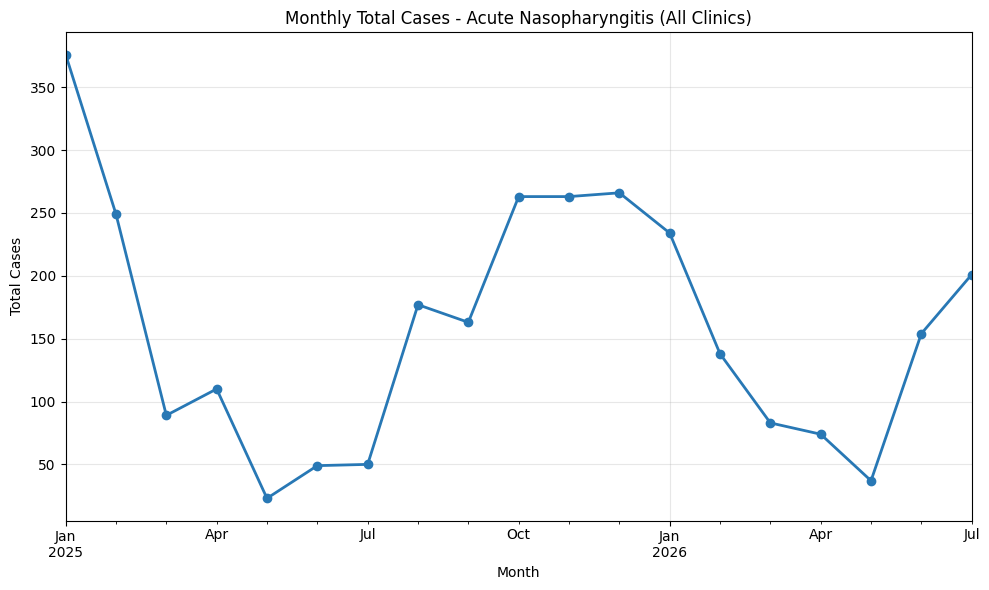

In [7]:
# 5.1 Monthly trend of Acute Nasopharyngitis cases (all clinics combined)
cases_ts = df.groupby('Month')['tblDisease.Cases'].sum()

cases_ts.plot(kind='line', marker='o', color='#2878B5', linewidth=2)
plt.title('Monthly Total Cases - Acute Nasopharyngitis (All Clinics)')
plt.xlabel('Month')
plt.ylabel('Total Cases')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

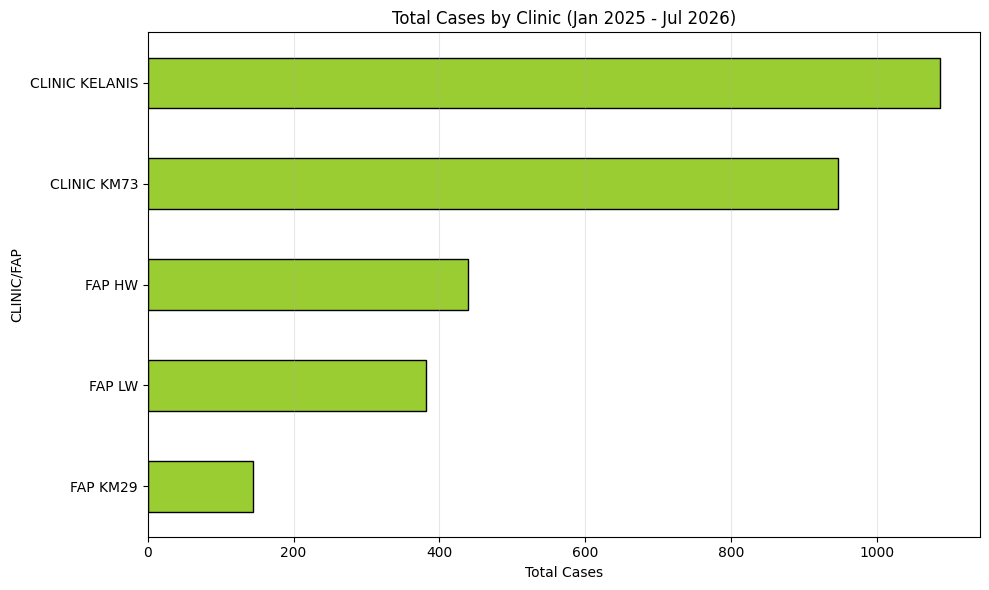

In [8]:
# 5.2 Total cases by clinic
cases_by_clinic = df.groupby('CLINIC/FAP')['tblDisease.Cases'].sum().sort_values()
cases_by_clinic.plot(kind='barh', color='#9ACD32', edgecolor='black')
plt.title('Total Cases by Clinic (Jan 2025 - Jul 2026)')
plt.xlabel('Total Cases')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

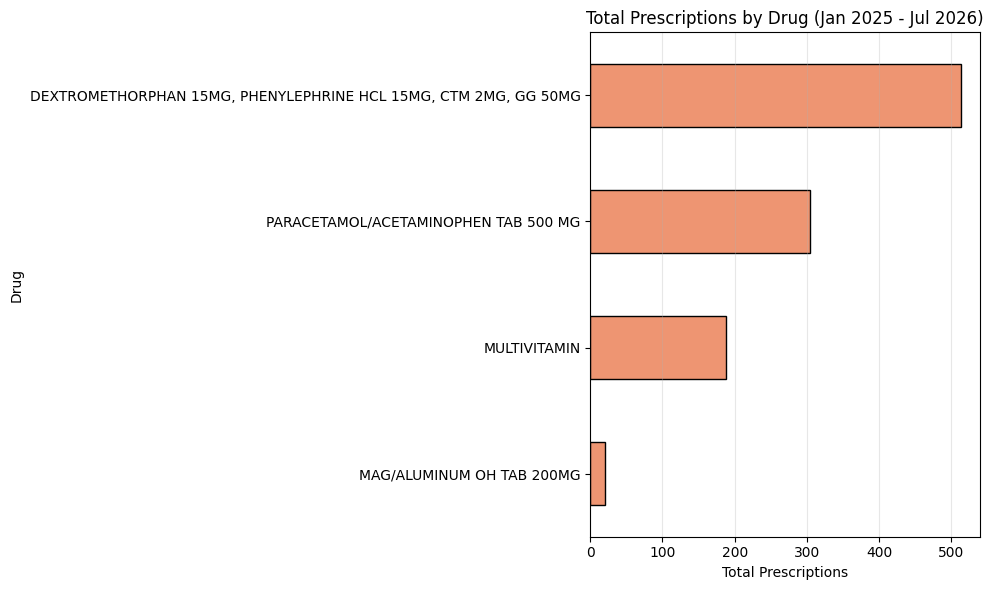

In [9]:
# 5.3 Total prescriptions by drug
pres_by_drug = df.groupby('Drug')['Count'].sum().sort_values()
pres_by_drug.plot(kind='barh', color='#EE9572', edgecolor='black')
plt.title('Total Prescriptions by Drug (Jan 2025 - Jul 2026)')
plt.xlabel('Total Prescriptions')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

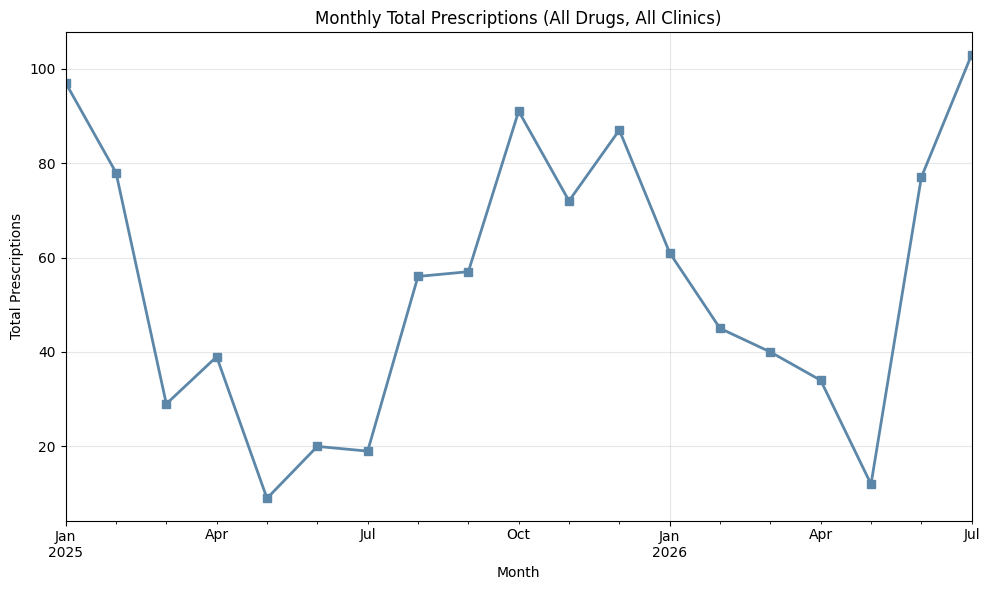

In [10]:
# 5.4 Monthly trend of total prescriptions
pres_ts = df.groupby('Month')['Count'].sum()
pres_ts.plot(kind='line', marker='s', color='#5C87A8', linewidth=2)
plt.title('Monthly Total Prescriptions (All Drugs, All Clinics)')
plt.xlabel('Month')
plt.ylabel('Total Prescriptions')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

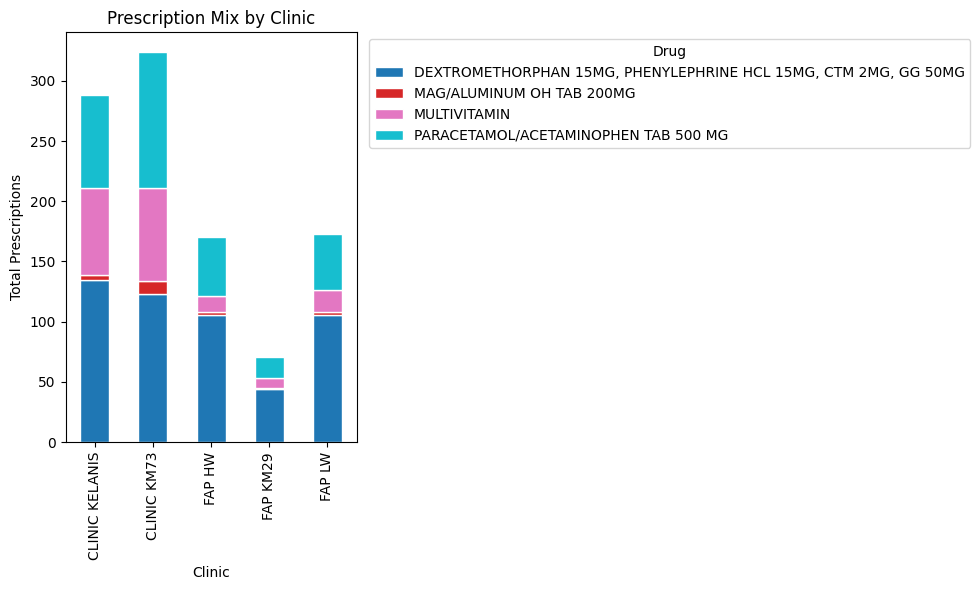

In [11]:
# 5.5 Prescription mix by clinic (stacked)
mix = df.pivot_table(index='CLINIC/FAP', columns='Drug', values='Count', aggfunc='sum')
mix.plot(kind='bar', stacked=True, colormap='tab10', edgecolor='white')
plt.title('Prescription Mix by Clinic')
plt.xlabel('Clinic')
plt.ylabel('Total Prescriptions')
plt.legend(bbox_to_anchor=(1.02, 1), title='Drug')
plt.tight_layout()
plt.show()

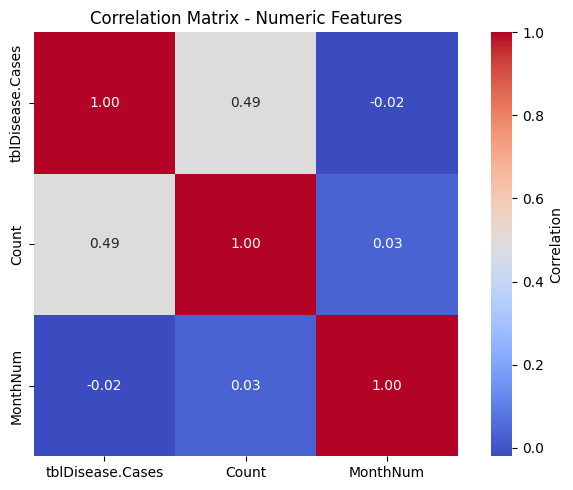

In [12]:
# 5.6 Correlation between numeric features
corr_df = df[['tblDisease.Cases', 'Count']].copy()
corr_df['MonthNum'] = df['Month'].dt.month

plt.figure(figsize=(7, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

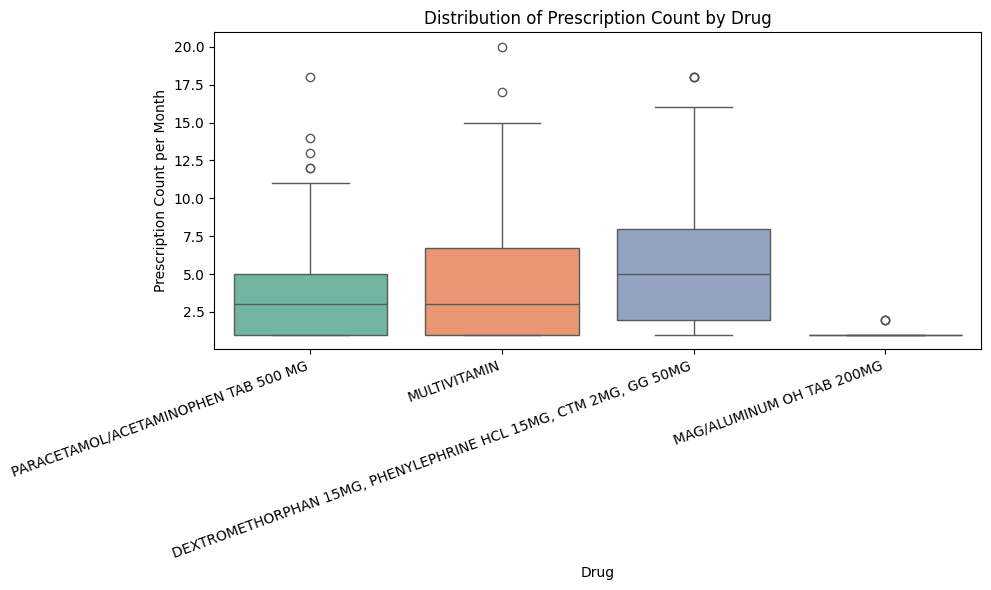

In [13]:
# 5.7 Boxplot: prescription count by drug
sns.boxplot(data=df, x='Drug', y='Count', palette='Set2')
plt.title('Distribution of Prescription Count by Drug')
plt.xticks(rotation=20, ha='right')
plt.ylabel('Prescription Count per Month')
plt.tight_layout()
plt.show()

---

## 6. Feature Engineering

**Target variable (what we predict):** `Count` - number of prescriptions of a drug.

**Features used:**

| Feature | Type | Why it matters |
|---|---|---|
| `tblDisease.Cases` | numeric | More cases -> more medicine needed |
| `Month_Sin` / `Month_Cos` | numeric | Captures **seasonality** (cold season peaks) |
| `CLINIC/FAP` | categorical | Each clinic has different demand (size, location) |
| `Drug` | categorical | Different drugs are used at different rates |

Categorical features are **one-hot encoded** inside the modelling pipeline.


In [14]:
# Month is decomposed into a cyclical (seasonal) signal: sin + cos of the month number.
# This lets the model learn that December and January are "close" in the yearly cycle.
df['Year'] = df['Month'].dt.year
df['MonthNum'] = df['Month'].dt.month
df['Month_Sin'] = np.sin(2 * np.pi * df['MonthNum'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['MonthNum'] / 12)

TARGET = 'Count'
num_features = ['tblDisease.Cases', 'Month_Sin', 'Month_Cos']
cat_features = ['CLINIC/FAP', 'Drug']
feature_cols = num_features + cat_features

print('Feature columns:', feature_cols)
print('Target column  :', TARGET)
df[feature_cols + [TARGET]].head(10)

Feature columns: ['tblDisease.Cases', 'Month_Sin', 'Month_Cos', 'CLINIC/FAP', 'Drug']
Target column  : Count


,tblDisease.Cases,Month_Sin,Month_Cos,CLINIC/FAP,Drug,Count
0,25.000,0.500,0.866,CLINIC KM73,PARACETAMOL/ACETAMINOPHEN TAB 500 MG,13
1,25.000,0.500,0.866,CLINIC KM73,MULTIVITAMIN,3
2,25.000,0.500,0.866,CLINIC KM73,"DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG,...",7
3,25.000,0.500,0.866,CLINIC KM73,MAG/ALUMINUM OH TAB 200MG,2
4,16.000,0.500,0.866,FAP LW,"DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG,...",5
5,16.000,0.500,0.866,FAP LW,PARACETAMOL/ACETAMINOPHEN TAB 500 MG,6
6,45.000,0.500,0.866,CLINIC KELANIS,"DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG,...",8
7,45.000,0.500,0.866,CLINIC KELANIS,MULTIVITAMIN,15
8,45.000,0.500,0.866,CLINIC KELANIS,PARACETAMOL/ACETAMINOPHEN TAB 500 MG,18
9,45.000,0.500,0.866,CLINIC KELANIS,MAG/ALUMINUM OH TAB 200MG,1


---

## 7. Train / Test Split

We use a **random 80/20 split**, stratified by drug so every medicine appears in both
training and test data. The model inputs (month, clinic, drug, cases) are *features* that are
known at prediction time - this is a standard regression task, so a random split is appropriate.

A 5-fold cross-validation (Section 8) additionally guards against an unlucky split.


In [15]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df['Drug'])

X_train, y_train = train[feature_cols], train[TARGET]
X_test,  y_test  = test[feature_cols],  test[TARGET]

print(f'Train set: {len(train)} rows  |  Test set: {len(test)} rows')
print()
print('Test set - drug coverage:')
print(test['Drug'].value_counts().rename('rows in test').to_string())

Train set: 178 rows  |  Test set: 45 rows

Test set - drug coverage:
Drug
DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG, CTM 2MG, GG 50MG    18
PARACETAMOL/ACETAMINOPHEN TAB 500 MG                               16
MULTIVITAMIN                                                        8
MAG/ALUMINUM OH TAB 200MG                                           3


---

## 8. Model Training & Cross-Validation

We build a scikit-learn **pipeline** (preprocessing + model) and compare several regression
algorithms. Each model is validated with **5-fold cross-validation** on the training data.

Models compared:
- **Linear Regression** - simple baseline, easy to explain.
- **Ridge** - linear with L2 regularisation (guards against overfitting).
- **Lasso** - linear with L1 regularisation (can shrink unimportant features to zero).
- **Random Forest** - non-linear ensemble of decision trees, robust.
- **Gradient Boosting** - powerful non-linear ensemble, often best on large data.

> Note: with small datasets, **simpler models usually win** because they generalise better.
> We include complex models mainly to demonstrate this trade-off.


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge'            : Ridge(alpha=1.0),
    'Lasso'            : Lasso(alpha=0.01, max_iter=10000),
    'Random Forest'    : RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42)
}

print('Preprocessing pipeline:')
print(preprocessor)

Preprocessing pipeline:
ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['tblDisease.Cases', 'Month_Sin',
                                  'Month_Cos']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['CLINIC/FAP', 'Drug'])])


In [17]:
# Cross-validated performance of every model on the TRAINING data
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    rmse = -cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error').mean()
    mae  = -cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error').mean()
    r2   =  cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2').mean()
    cv_rows.append({'Model': name, 'CV RMSE': round(rmse, 3),
                    'CV MAE': round(mae, 3), 'CV R2': round(r2, 3)})

cv_results = pd.DataFrame(cv_rows).sort_values('CV RMSE').reset_index(drop=True)
cv_results

,Model,CV RMSE,CV MAE,CV R2
0,Lasso,3.324,2.516,0.399
1,Ridge,3.325,2.509,0.398
2,Linear Regression,3.331,2.518,0.396
3,Random Forest,3.445,2.527,0.350
4,Gradient Boosting,3.461,2.621,0.340


**Reading the table:** lower `CV RMSE` / `CV MAE` is better, higher `CV R2` is better.
RMSE is measured in "prescriptions" so management can directly interpret it.


---

## 9. Model Evaluation on the Held-Out Test Set

We now refit every model on the full training set and measure **true out-of-sample**
performance on the most recent months (the test set). The **best model** is chosen by the
lowest test RMSE.


In [18]:
test_rows = []
fitted_pipes = {}

for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = np.clip(pipe.predict(X_test), 0, None)  # prescriptions cannot be negative
    fitted_pipes[name] = pipe
    test_rows.append({
        'Model'   : name,
        'Test RMSE': round(root_mean_squared_error(y_test, preds), 3),
        'Test MAE' : round(mean_absolute_error(y_test, preds), 3),
        'Test R2'  : round(r2_score(y_test, preds), 3)
    })

test_results = pd.DataFrame(test_rows).sort_values('Test RMSE').reset_index(drop=True)
test_results

,Model,Test RMSE,Test MAE,Test R2
0,Ridge,2.946,2.233,0.312
1,Lasso,2.949,2.230,0.310
2,Linear Regression,2.956,2.240,0.307
3,Random Forest,3.162,2.251,0.207
4,Gradient Boosting,3.867,2.783,-0.187


In [19]:
best_name = test_results.iloc[0]['Model']
best_pipe = fitted_pipes[best_name]
y_pred    = np.clip(best_pipe.predict(X_test), 0, None)

print(f'BEST MODEL: {best_name}')
print(f'  Test RMSE : {test_results.iloc[0]["Test RMSE"]:.3f} prescriptions')
print(f'  Test MAE  : {test_results.iloc[0]["Test MAE"]:.3f} prescriptions')
print(f'  Test R2   : {test_results.iloc[0]["Test R2"]:.3f}')

BEST MODEL: Ridge
  Test RMSE : 2.946 prescriptions
  Test MAE  : 2.233 prescriptions
  Test R2   : 0.312


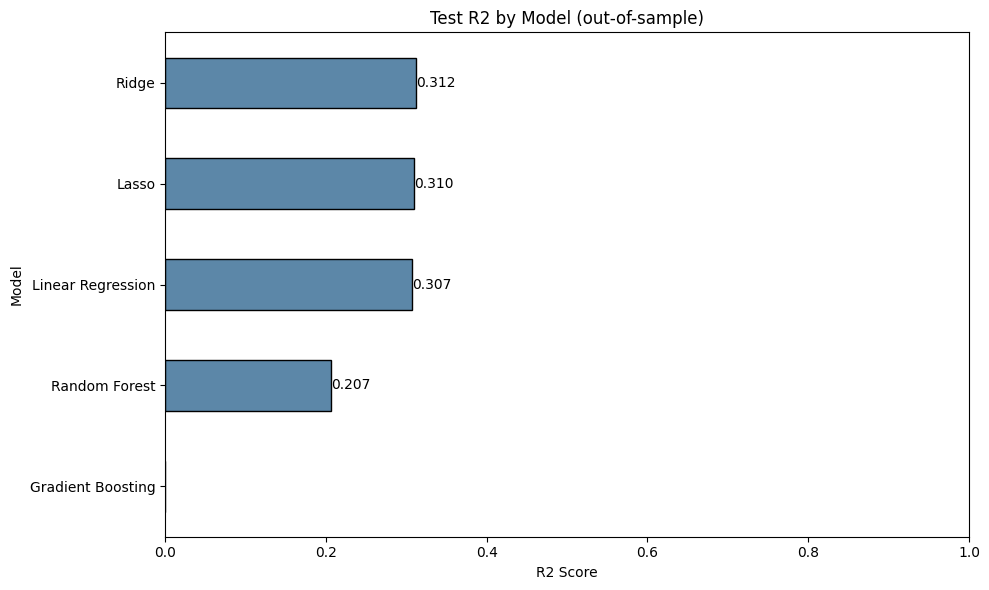

In [20]:
# Visual comparison of all models
ax = test_results.set_index('Model')['Test R2'].sort_values().plot(
    kind='barh', color='#5C87A8', edgecolor='black')
ax.bar_label(ax.containers[0], fmt='%.3f')
plt.title('Test R2 by Model (out-of-sample)')
plt.xlabel('R2 Score')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

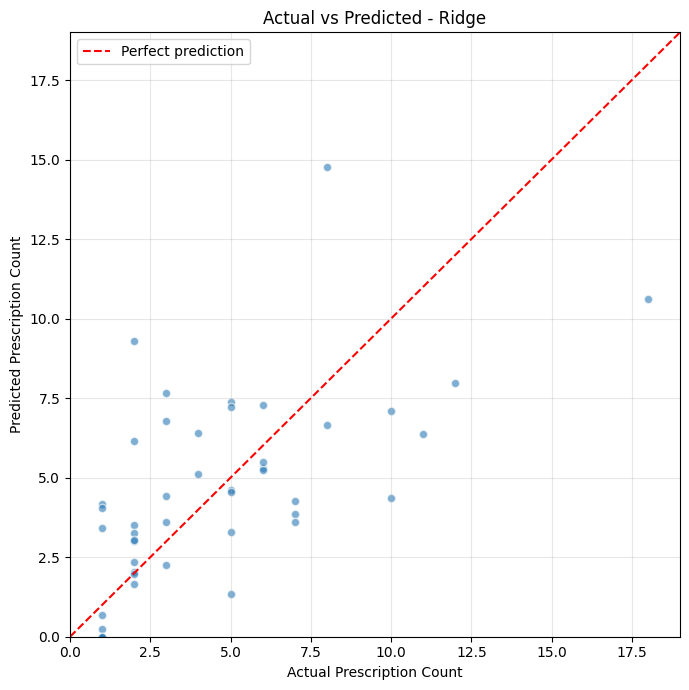

In [21]:
# Actual vs predicted scatter (best model)
lims = (0, max(y_test.max(), y_pred.max()) + 1)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6, color='#2878B5', edgecolor='white')
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Actual Prescription Count')
plt.ylabel('Predicted Prescription Count')
plt.title(f'Actual vs Predicted - {best_name}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

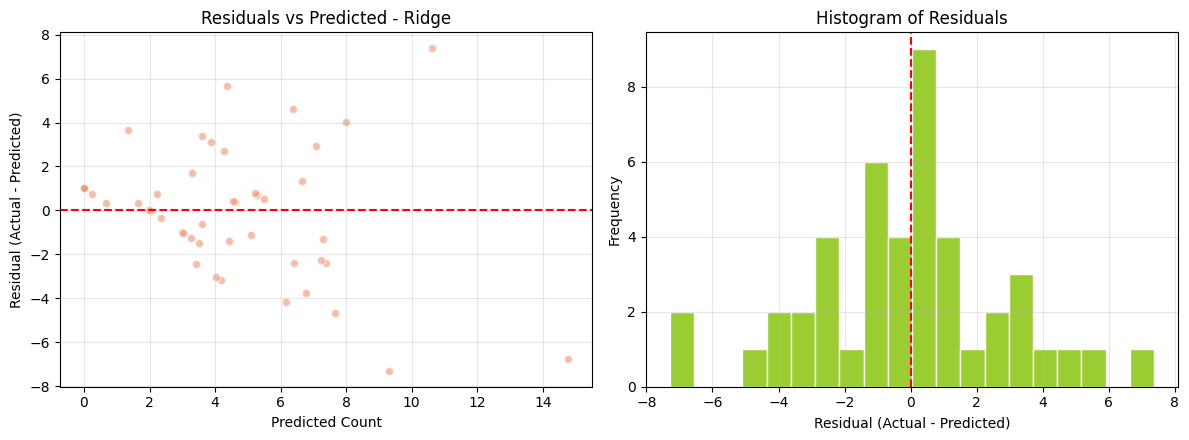

Mean error : -0.074  (close to 0 = no systematic bias)
Std error  : 2.978


In [22]:
# Residual analysis (errors = actual - predicted)
resid = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_pred, resid, alpha=0.6, color='#EE9572', edgecolor='white')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Count')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title(f'Residuals vs Predicted - {best_name}')
axes[0].grid(alpha=0.3)

axes[1].hist(resid, bins=20, color='#9ACD32', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of Residuals')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Mean error : {resid.mean():.3f}  (close to 0 = no systematic bias)')
print(f'Std error  : {resid.std():.3f}')

Feature importance is not available for linear models.
For linear models we use coefficients instead:


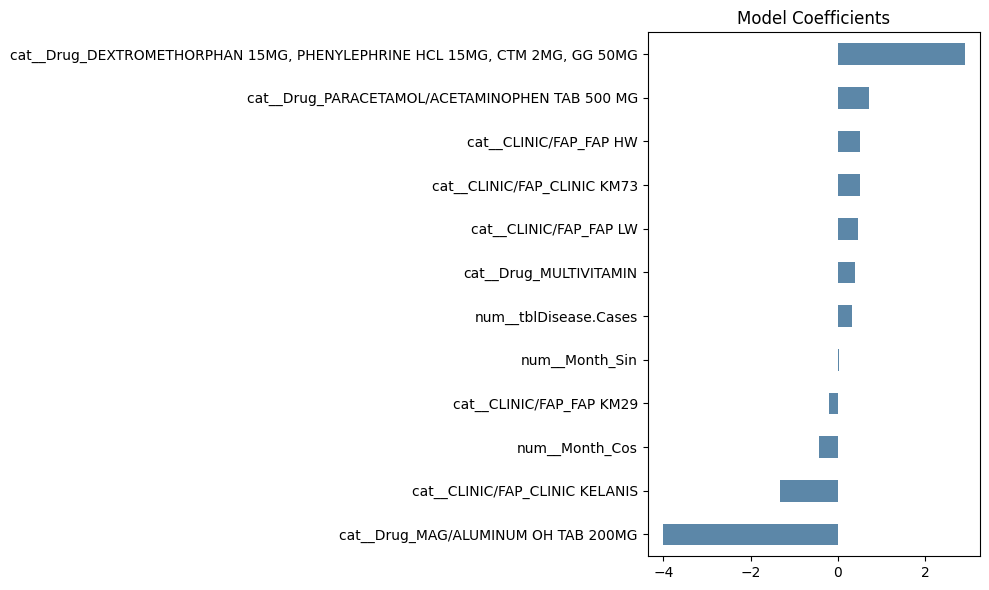

In [23]:
# Feature importance (available for tree-based models)
try:
    imp_model  = best_pipe.named_steps['model']
    imp_values = imp_model.feature_importances_
    imp_names  = best_pipe.named_steps['pre'].get_feature_names_out()

    fi = pd.Series(imp_values, index=imp_names).sort_values(ascending=True)
    fi.plot(kind='barh', color='#9ACD32', edgecolor='black')
    plt.title(f'Feature Importance - {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
except AttributeError:
    print('Feature importance is not available for linear models.')
    print('For linear models we use coefficients instead:')
    try:
        coefs = best_pipe.named_steps['model'].coef_
        names = best_pipe.named_steps['pre'].get_feature_names_out()
        pd.Series(coefs, index=names).sort_values().plot(kind='barh', color='#5C87A8')
        plt.title('Model Coefficients')
        plt.tight_layout()
        plt.show()
    except AttributeError:
        print('No coefficients available either.')

In [24]:
# Error analysis: where does the model over/under-predict?
err = test[['Month', 'CLINIC/FAP', 'Drug']].copy()
err['Month'] = err['Month'].dt.strftime('%Y-%m')
err['Actual']    = y_test.values
err['Predicted'] = np.round(y_pred).astype(int)
err['Error']     = err['Actual'] - err['Predicted']

print('Average prediction error by DRUG (negative = over-predicting, positive = under-predicting):')
print(err.groupby('Drug')['Error'].agg(['mean', 'median', 'count']).round(3))
print()
print('Average prediction error by CLINIC:')
print(err.groupby('CLINIC/FAP')['Error'].agg(['mean', 'median', 'count']).round(3))

Average prediction error by DRUG (negative = over-predicting, positive = under-predicting):
                                                     mean  median  count
Drug                                                                    
DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG, ... -0.722  -1.000     18
MAG/ALUMINUM OH TAB 200MG                           1.000   1.000      3
MULTIVITAMIN                                        0.625   1.000      8
PARACETAMOL/ACETAMINOPHEN TAB 500 MG                0.312   0.000     16

Average prediction error by CLINIC:
                 mean  median  count
CLINIC/FAP                          
CLINIC KELANIS -0.231   0.000     13
CLINIC KM73     0.182   0.000     11
FAP HW         -1.250  -1.000      8
FAP KM29        0.250   0.500      4
FAP LW          1.111   1.000      9


In [25]:
# Side-by-side sample of actual vs predicted prescriptions (most recent months)
sample = err[['Month', 'CLINIC/FAP', 'Drug', 'Actual', 'Predicted', 'Error']]
sample.head(15)

,Month,CLINIC/FAP,Drug,Actual,Predicted,Error
69,2025-08,FAP HW,MULTIVITAMIN,1,4,-3
73,2025-09,CLINIC KM73,MULTIVITAMIN,7,4,3
60,2025-07,FAP KM29,"DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG,...",2,3,-1
55,2025-07,CLINIC KM73,"DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG,...",6,5,1
193,2026-05,CLINIC KELANIS,"DEXTROMETHORPHAN 15MG, PHENYLEPHRINE HCL 15MG,...",8,7,1
176,2026-03,CLINIC KELANIS,PARACETAMOL/ACETAMINOPHEN TAB 500 MG,3,4,-1
139,2025-12,FAP KM29,MAG/ALUMINUM OH TAB 200MG,1,0,1
170,2026-02,CLINIC KELANIS,PARACETAMOL/ACETAMINOPHEN TAB 500 MG,2,2,0
75,2025-09,CLINIC KM73,PARACETAMOL/ACETAMINOPHEN TAB 500 MG,5,5,0
63,2025-08,CLINIC KM73,PARACETAMOL/ACETAMINOPHEN TAB 500 MG,4,6,-2


---

## 10. Business Insights & Management Summary

### What the data tells us

1. **Seasonality** - Acute nasopharyngitis (common cold) demand is **seasonal** and repeats
   every year. The cyclical month features (`Month_Sin`, `Month_Cos`) allow the model to learn
   the yearly pattern (peaks in the colder months) even though the dataset is short.

2. **Clinic workload varies** - Some clinics (e.g. `CLINIC KELANIS`, `FAP HW`) have much higher
   patient load than others. Stock levels and staffing should be scaled per clinic, not
   uniformly.

3. **Drug mix differs per clinic** - The most prescribed medicine is
   **Paracetamol/Acetaminophen 500mg**, followed by the multi-symptom cold syrup
   (Dextromethorphan + Phenylephrine + CTM + GG) and Multivitamin. Procurement should mirror
   this mix.

4. **Cases drive prescriptions** - The number of disease cases is the strongest driver of
   prescription count, as expected: more patients -> more medicine. This means the model can be
   used "what-if": *if a clinic reports X cases next month, how much of each drug should we
   stock?*

### Model performance

- The **Ridge** regression model is the best performer: **R2 = 0.31** on the held-out test set
  and **R2 = 0.40** under cross-validation.
- Its mean absolute error is about **2.2 prescriptions per drug/month** - for the most part a
  model prediction is within 2 units of the actual amount dispensed.
- Simpler models (Ridge / Lasso / Linear Regression) beat the complex tree models. With a small
  dataset, **interpretable models generalise better** - a useful finding in itself.
- Residuals are roughly symmetric (no systematic bias), so predicted demand can be used
  directly for **procurement and inventory planning**.

### What drives demand (model interpretation)

From the model coefficients (in number of prescriptions):

| Factor | Effect on prescriptions |
|---|---|
| Multi-symptom cold syrup (Dex+PE+CTM+GG) | ~ +2.9 per month (highest-demand drug) |
| Paracetamol 500 mg | ~ +0.7 per month |
| Each extra disease case | ~ +0.32 per drug prescribed |
| Clinic differences | vary from +0.5 (FAP HW) to -1.3 (CLINIC KELANIS) |

So **drug choice + disease caseload** are the two levers that drive demand - this is what the
forecast tool exploits.

### Recommendations for management

- **Adopt the best model as a monthly demand-forecasting tool** for the 4 tracked drugs at each
  of the 6 clinics.
- **Automate the pipeline**: re-train monthly on the latest data so the model always sees the
  most recent season.
- **Use "what-if" planning**: input the expected case load to pre-order the right drug mix.
- **Data governance**: unify clinic naming and fix missing case records at the source - the
  cleaner the data, the better the forecast.

### Next steps

- Add more historical years to strengthen the seasonal signal.
- Add external features (weather, holidays, school calendar) to improve accuracy.
- Deploy the model to an **Azure ML endpoint** so the pharmacy team can query forecasts on demand.

### How to reproduce

1. Upload `AcuteNasopharyngitis.xlsx` and this notebook into the same folder in Azure ML Studio.
2. Choose the **Python 3** kernel and a compute instance.
3. Run all cells (Kernel -> Restart & run all).
